![](https://media.giphy.com/media/3o6MbrACMlFCny8zmw/giphy.gif)

Remember the rules of ~Fight~ Code Club:
1. ALWAYS DOCUMENT
2. Cite resources that you use (paste links)
3. Include the names people who you worked with
4. Be neat and organized

# Question 1

Using the dataset "us-cities-top-1k-multi-year.csv":
1. Create a line graph of total population over time for the states: NY, PA, CT, NJ (10 pts)
2. Be sure to include a title of the graph, labels on your axis, and a legend. (5 pts)
3. Specify colors to be used in your code. (5 pts)

# Question 2

Using the dataset "us-cities-top-1k-multi-year.csv":
1. Create a Bar Graph of the total population for 5 cities in the state of New York comparing 2014 years and 2018 years (15 pts)
2. Be sure to include a title of the graph, labels on your axis, and a legend. (5 pts)
3. Combine the graph in question 1 and question 2 in one figure.

## Question 3

import the data "job-automation-probability.csv"
1. A Histogram of the variable 'probability'
2. A scatter plot of 'Average annual wage' and 'numbEmployed'
3. Put both of these graphs in one figure
4. Using item 3, change the ticks of Number Employed axes so that it is in logarithmic axis (hint: it's an option) 
5. Adding onto item 4, add a title and axis labels
6. Save your figure as a png

In [1]:
#Q1 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
us_cities = pd.read_csv('/Users/liza/Documents/GitHub/weekly-task-5-hikostra/weekly task 5/us-cities-top-1k-multi-year.csv')
us_cities

,City,State,Population,lat,lon,year
0,Marysville,Washington,63269,48.051764,-122.177082,2014
1,Perris,California,72326,33.782519,-117.228648,2014
2,Cleveland,Ohio,390113,41.499320,-81.694361,2014
3,Worcester,Massachusetts,182544,42.262593,-71.802293,2014
4,Columbia,South Carolina,133358,34.000710,-81.034814,2014
...,...,...,...,...,...,...
3995,West New York,New Jersey,724261,40.787879,-74.014306,2018
3996,Everett,Massachusetts,723882,42.408430,-71.053663,2018
3997,Linden,New Jersey,663947,40.622048,-74.244590,2018
3998,Asheville,North Carolina,492462,35.595058,-82.551487,2018


In [15]:
states = ["New York", "Pennsylvania", "Connecticut", "New Jersey"]
df = us_cities[us_cities["State"].isin(states)] #filter for states 

In [16]:
grouped_cities = df.groupby(["year", "State"])["Population"].sum().reset_index()
grouped_cities # group cities in each state and total it's population 

,year,State,Population
0,2014,Connecticut,1239817
1,2014,New Jersey,1859793
2,2014,New York,9933332
3,2014,Pennsylvania,2598080
4,2015,Connecticut,5502223
5,2015,New Jersey,8870245
6,2015,New York,5271074
7,2015,Pennsylvania,4883554
8,2016,Connecticut,7000555
9,2016,New Jersey,10569472


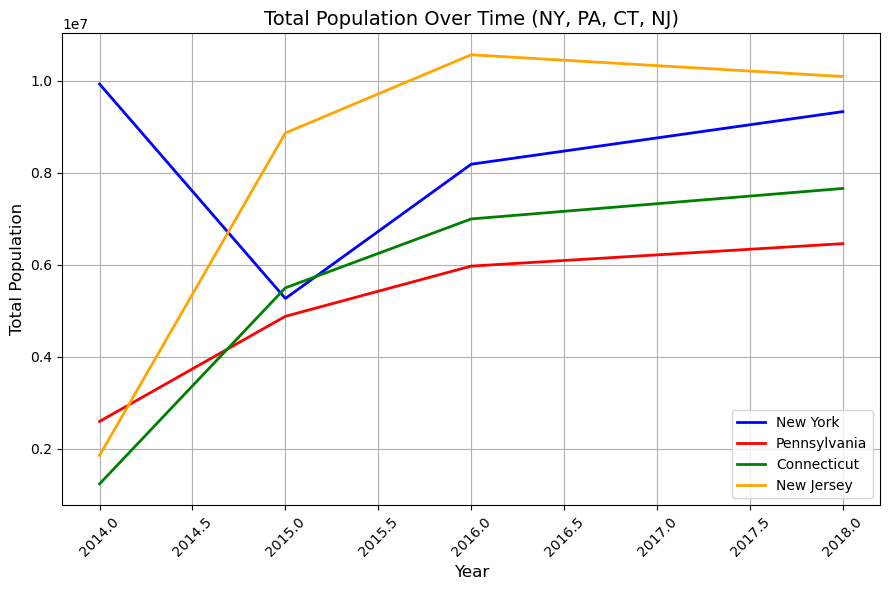

In [51]:
plt.figure(figsize=(9,6))

colors = ["blue", "red", "green", "orange"]

for i, state in enumerate(states):
    data = grouped_cities[grouped_cities["State"] == state]
    data = data.sort_values("year")
    plt.plot(data["year"], data["Population"], label=state, color=colors[i], linewidth=2)

plt.title("Total Population Over Time (NY, PA, CT, NJ)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Population", fontsize=12)

plt.xticks(rotation=45) #angle years so they not cover each other 
plt.legend()
plt.grid(True) #creatibg a grid for easier visualisation 

plt.tight_layout()
plt.show()

In [25]:
#Q2

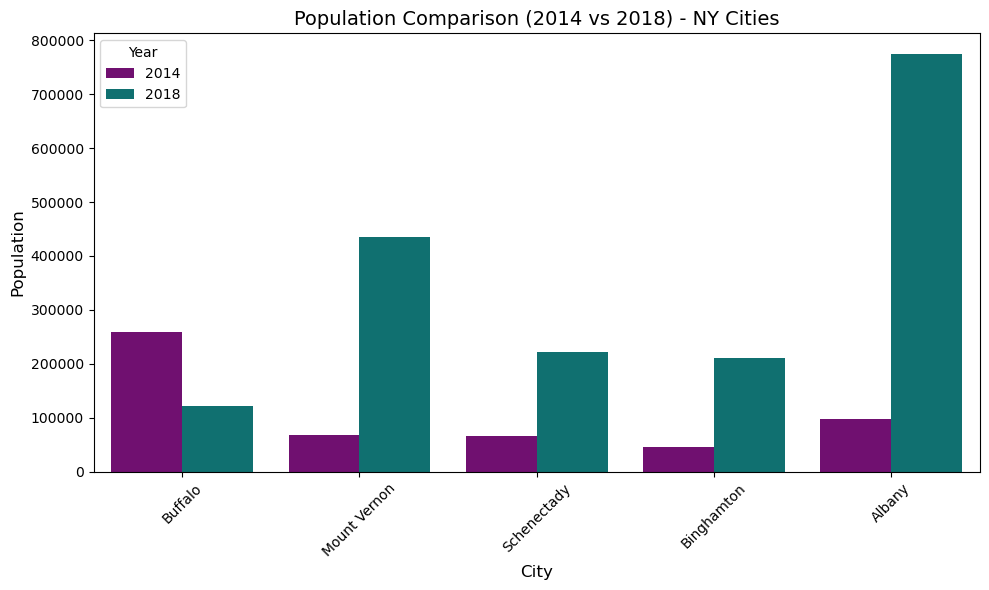

In [60]:
ny = us_cities[us_cities["State"] == "New York"]

cities = ny["City"].unique()[:5]

df_ny = ny[(ny["City"].isin(cities)) & (ny["year"].isin([2014, 2018]))]

plt.figure(figsize=(10,6))

sns.barplot(data=df_ny, x="City", y="Population", hue="year", palette=["purple", "teal"])

plt.title("Population Comparison (2014 vs 2018) - NY Cities", fontsize=14)
plt.xlabel("City", fontsize=12)
plt.ylabel("Population", fontsize=12)

plt.xticks(rotation=45) #angle cities so they not cover each other 
plt.legend(title="Year")

plt.tight_layout()
plt.show()

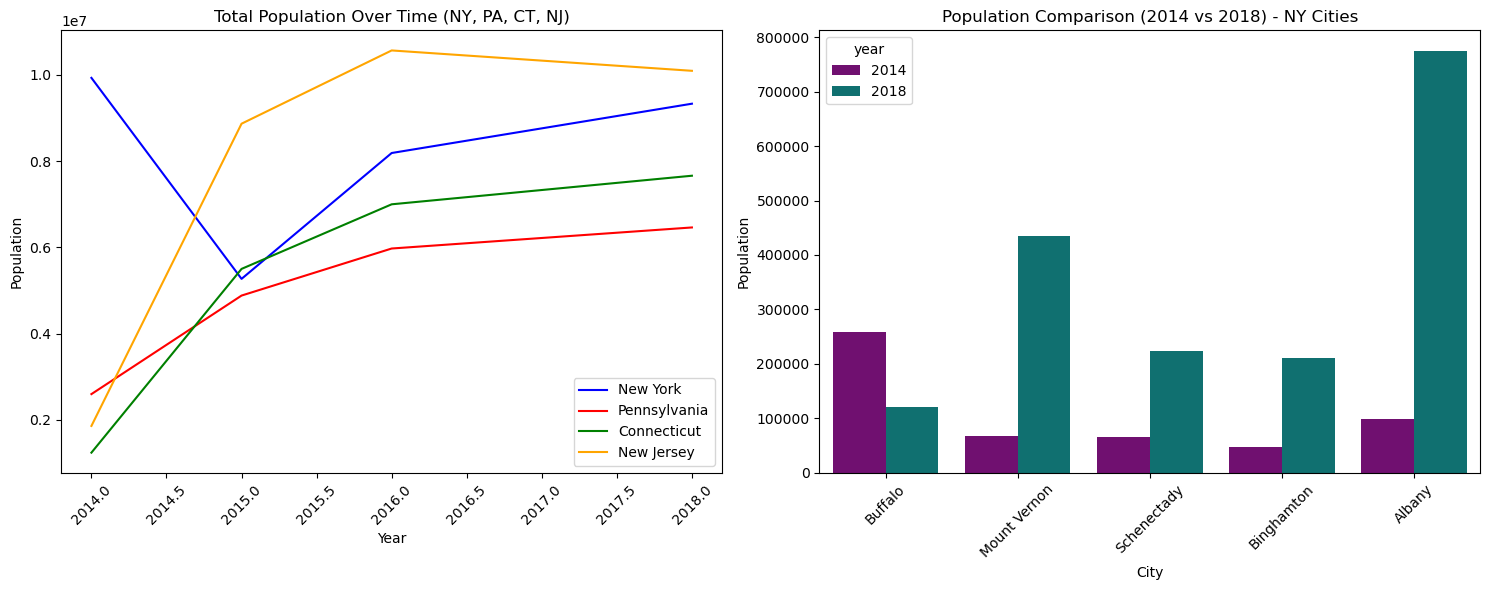

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,6))

#1st graph
plt.subplot(1, 2, 1)

colors = ["blue", "red", "green", "orange"]

for i, state in enumerate(states):
    data = grouped_cities[grouped_cities["State"] == state]
    data = data.sort_values("year")
    plt.plot(data["year"], data["Population"], label=state, color=colors[i])

plt.title("Total Population Over Time (NY, PA, CT, NJ)")
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend()
plt.xticks(rotation=45)


#2nd graph
plt.subplot(1, 2, 2)

sns.barplot(data=df_ny, x="City", y="Population", hue="year",palette=["purple", "teal"])

plt.title("Population Comparison (2014 vs 2018) - NY Cities")
plt.xlabel("City")
plt.ylabel("Population")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [62]:
#Q3

In [63]:
jobs = pd.read_csv('/Users/liza/Documents/GitHub/weekly-task-5-hikostra/weekly task 5/job-automation-probability.csv')
jobs

,_ - rank,_ - code,prob,Average annual wage,education,occupation,short occupation,len,probability,numbEmployed,median_ann_wage,employed_may2016,average_ann_wage
0,624,51-4033,0.9500,34920.0,High school diploma or equivalent,"Grinding, Lapping, Polishing and Buffing Machi...","Tool setters, operators and tenders",35,0.9500,74600,32890.0,74600,34920.0
1,517,51-9012,0.8800,41450.0,High school diploma or equivalent,"Separating, Filtering, Clarifying, Precipitati...","Tool setters, operators and tenders",35,0.8800,47160,38360.0,47160,41450.0
2,484,41-4012,0.8500,68410.0,High school diploma or equivalent,"Sales Representatives, Wholesale and Manufactu...","Sales Representatives, Wholesale and Manufactu...",92,0.8500,1404050,57140.0,1404050,68410.0
3,105,53-1031,0.0290,59800.0,High school diploma or equivalent,First-Line Supervisors of Transportation and M...,Supervisors Transportation,26,0.0290,202760,57270.0,202760,59800.0
4,620,51-4072,0.9500,32660.0,High school diploma or equivalent,"Molding, Coremaking and Casting Machine Setter...","Molding, Coremaking and Casting Machine Setter...",89,0.9500,145560,30480.0,145560,32660.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
697,259,27-2011,0.3700,71313.6,"Some college, no degree",Actors,Actors,6,0.3700,48620,33473.0,48620,71313.6
698,522,51-3011,0.8900,27110.0,No formal educational credential,Bakers,Bakers,6,0.8900,180450,25090.0,180450,27110.0
699,42,21-2011,0.0081,49450.0,Bachelor's degree,Clergy,Clergy,6,0.0081,49320,45740.0,49320,49450.0
700,669,41-9012,0.9800,36560.0,No formal educational credential,Models,Models,6,0.9800,4390,21870.0,4390,36560.0


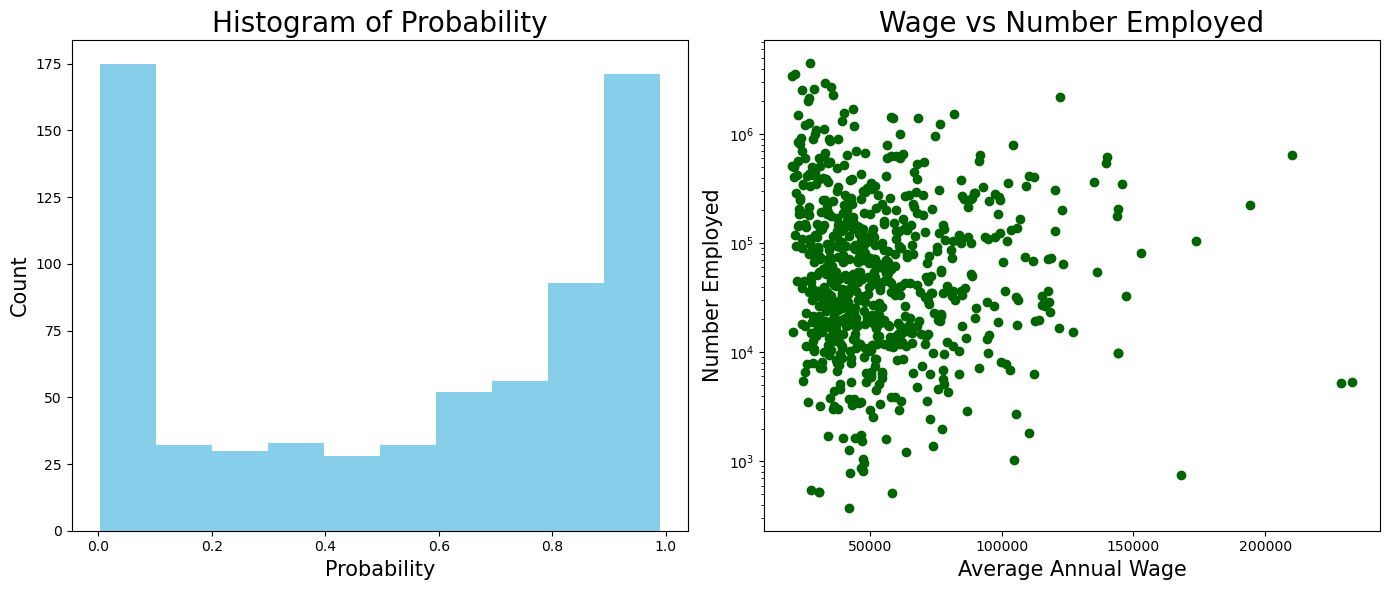

In [64]:
plt.figure(figsize=(14,6))

#Histogram
plt.subplot(1, 2, 1)
plt.hist(jobs['probability'], bins=10, color='skyblue')
plt.xlabel('Probability', fontsize=15)
plt.ylabel('Count', fontsize=15)
plt.title("Histogram of Probability", fontsize=20)


#Scatter plot
plt.subplot(1, 2, 2)
plt.scatter(jobs['Average annual wage'], jobs['numbEmployed'], color='darkgreen')
plt.yscale('log')
plt.xlabel('Average Annual Wage', fontsize=15)
plt.ylabel('Number Employed', fontsize=15)
plt.title("Wage vs Number Employed", fontsize=20)

plt.tight_layout()
plt.savefig("jobs_figure.png")

plt.show()